# Task 2

## Integrantes
- Sergio Orellana 221122
- Rodrigo Mansilla 22611
- Ricardo Chuy 221007



### Prompt utilizado con IA

> Actúa como ingeniero de visión artificial. Tengo dos imágenes: la imagen base (izquierda) y la imagen
> warped (derecha transformada). Escribe un código en Python que genere una imagen compuesta
> (blending) donde la imagen base se muestre en el canal Rojo y la imagen warped en el canal Cian
> (Verde+Azul). Esto debe crear un efecto de anaglifo donde los píxeles perfectamente alineados se vean en
> escala de grises y los errores se vean como bordes de colores.


In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

# Mostrar figuras dentro de Jupyter (sin ventanas externas).
%matplotlib qt


In [3]:
def compute_anaglyph(left_img_path, right_img_path, min_match_count=20):
    # Calcula la homografía entre la imagen derecha (Query) y la izquierda (Train/Base),

    # Leer imágenes
    img_left = cv2.imread(left_img_path)
    img_right = cv2.imread(right_img_path)

    if img_left is None or img_right is None:
        raise FileNotFoundError("Revisa las rutas de las imágenes experimental izquierda/derecha.")

    gray_left = cv2.cvtColor(img_left, cv2.COLOR_BGR2GRAY)
    gray_right = cv2.cvtColor(img_right, cv2.COLOR_BGR2GRAY)

    sift = cv2.SIFT_create()
    kp_left, des_left = sift.detectAndCompute(gray_left, None)   # Train / Destino
    kp_right, des_right = sift.detectAndCompute(gray_right, None)  # Query / Origen

    FLANN_INDEX_KDTREE = 1
    index_params = dict(algorithm=FLANN_INDEX_KDTREE, trees=5)
    search_params = dict(checks=50)
    flann = cv2.FlannBasedMatcher(index_params, search_params)

    matches = flann.knnMatch(des_right, des_left, k=2)  # Query vs Train

    good_matches = []
    for m, n in matches:
        if m.distance < 0.7 * n.distance:
            good_matches.append(m)

    if len(good_matches) < min_match_count:
        raise ValueError(f"No hay suficientes good matches ({len(good_matches)}) para estimar una homografía estable.")

    src_pts = np.float32([kp_right[m.queryIdx].pt for m in good_matches]).reshape(-1, 1, 2)  # derecha
    dst_pts = np.float32([kp_left[m.trainIdx].pt for m in good_matches]).reshape(-1, 1, 2)   # izquierda

    H, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)

    h_left, w_left = img_left.shape[:2]
    warped_right = cv2.warpPerspective(img_right, H, (w_left, h_left))

    base_gray = gray_left
    warped_gray = cv2.cvtColor(warped_right, cv2.COLOR_BGR2GRAY)

    anaglyph = np.zeros((h_left, w_left, 3), dtype=np.uint8)
    anaglyph[:, :, 0] = base_gray          # Canal R
    anaglyph[:, :, 1] = warped_gray        # Canal G
    anaglyph[:, :, 2] = warped_gray        # Canal B

    return img_left, warped_right, anaglyph, H


### Task 2 – Ejecución del algoritmo de stitching en el set experimental

In [4]:
left_experimental_path = "img/experimental/izquierda4.jpg"
right_experimental_path = "img/experimental/derecha4.jpg"

img_left, warped_right, anaglyph, H = compute_anaglyph(left_experimental_path, right_experimental_path)

plt.figure(figsize=(10, 5))
plt.title("Anaglifo Rojo-Cian (izquierda base, derecha warpeda)")
plt.imshow(anaglyph)
plt.axis("off")
plt.show()


### Task 2.1 – Medición de la disparidad en píxeles


In [5]:
def medir_disparidad(anaglyph, output_path="img/results/puntos_disparidad.png"):
    """Mide disparidad (en píxeles), guarda evidencia y retorna la tabla ruta guardada."""

    h, w = anaglyph.shape[:2]
    fig_w = 12
    fig_h = fig_w * (h / w)

    plt.figure(figsize=(fig_w, fig_h))
    plt.title("Haz 6 clics: A_rojo, A_cian, B_rojo, B_cian, C_rojo, C_cian")
    plt.imshow(anaglyph)
    plt.axis("on")

    print("Hacer seis clicks en este orden:")
    print("   1) A_rojo, 2) A_cian, 3) B_rojo, 4) B_cian, 5) C_rojo, 6) C_cian")
    puntos = plt.ginput(6, timeout=0)

    if len(puntos) != 6:
        raise ValueError(f"Se esperaban 6 puntos, pero se capturaron {len(puntos)}.")

    xs = [float(p[0]) for p in puntos]
    ys = [float(p[1]) for p in puntos]

    disparidades = [
        abs(xs[0] - xs[1]),  # A
        abs(xs[2] - xs[3]),  # B
        abs(xs[4] - xs[5])   # C
    ]

    # Distancias reales estimadas (m) coherentes con cercano/medio/fondo.
    distancias_estimadas_m = [1.5, 3.0, 5.0]

    tabla = pd.DataFrame({
        "Objeto": ["A (Cercano)", "B (Medio)", "C (Fondo)"],
        "Distancia Real Estimada (m)": distancias_estimadas_m,
        "Coordenada X Fantasma 1": [xs[0], xs[2], xs[4]],
        "Coordenada X Fantasma 2": [xs[1], xs[3], xs[5]],
        "Disparidad (|x1 - x2|) en pixeles": disparidades
    })

    plt.close()

    # Visualización final de evidencia (después del análisis).
    plt.figure(figsize=(fig_w, fig_h))
    plt.title("Puntos seleccionados para medición de disparidad")
    plt.imshow(anaglyph)
    plt.axis("on")

    colores = ["yellow", "yellow", "lime", "lime", "magenta", "magenta"]
    etiquetas = ["A_rojo", "A_cian", "B_rojo", "B_cian", "C_rojo", "C_cian"]

    for i, (x, y) in enumerate(puntos):
        plt.scatter(x, y, s=60, c=colores[i], edgecolors="black", linewidths=0.8)
        plt.text(x + 8, y + 8, f"{i + 1}: {etiquetas[i]}", color=colores[i], fontsize=10, weight="bold")

    pares = [(0, 1), (2, 3), (4, 5)]
    for i, j in pares:
        plt.plot([xs[i], xs[j]], [ys[i], ys[j]], linestyle="--", linewidth=1.5, color="white")

    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(output_path, dpi=220, bbox_inches="tight")
    plt.show()

    return tabla, str(output_path)

# Ejecución interactiva
tabla_disparidad, ruta_resultado = medir_disparidad(anaglyph)
tabla_disparidad


Hacer seis clicks en este orden:
   1) A_rojo, 2) A_cian, 3) B_rojo, 4) B_cian, 5) C_rojo, 6) C_cian


,Objeto,Distancia Real Estimada (m),Coordenada X Fantasma 1,Coordenada X Fantasma 2,Disparidad (|x1 - x2|) en pixeles
0,A (Cercano),1.5,669.338384,896.893939,227.555556
1,B (Medio),3.0,1191.681818,1274.429293,82.747475
2,C (Fondo),5.0,622.792929,669.338384,46.545455


### Task 2.2 – Evidencia guardada en disco


In [9]:
%matplotlib inline

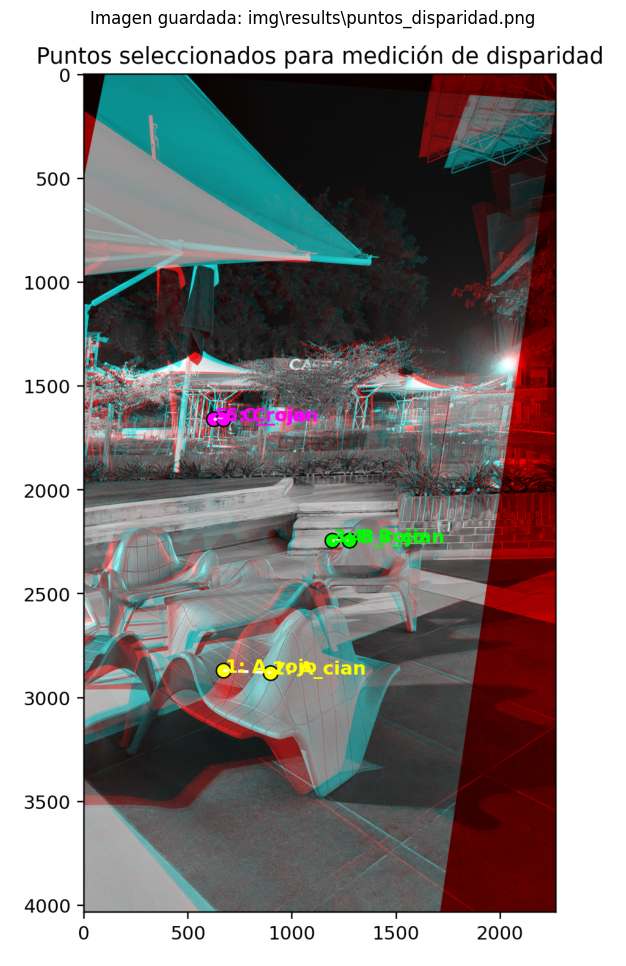

In [10]:
img_guardada = plt.imread(ruta_resultado)
plt.figure(figsize=(8, 12))
plt.title(f"Imagen guardada: {ruta_resultado}")
plt.imshow(img_guardada)
plt.axis("off")
plt.show()
